## Install ABSA

In [ ]:
!pip install aspect_based_sentiment_analysis

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 2.5 MB 7.7 MB/s 
     |████████████████████████████████| 348 kB 61.4 MB/s 
     |████████████████████████████████| 98 kB 4.7 MB/s 
     |████████████████████████████████| 454.3 MB 19 kB/s 
     |████████████████████████████████| 4.0 MB 81.7 MB/s 
     |████████████████████████████████| 14.8 MB 75.5 MB/s 
     |████████████████████████████████| 1.2 MB 76.6 MB/s 
     |████████████████████████████████| 462 kB 90.9 MB/s 
     |████████████████████████████████| 132 kB 87.9 MB/s 
     |████████████████████████████████| 880 kB 74.9 MB/s 
     |████████████████████████████████| 3.3 MB 74.8 MB/s 
     |████████████████████████████████| 1.6 MB 74.3 MB/s 
     |████████████████████████████████| 81 kB 10.5 MB/s 
     |████████████████████████████████| 209 kB 84.9 MB/s 
     |████████████████████████████████| 78 kB 9.5 MB/s 
     |██████████████████████████████

In [ ]:
import aspect_based_sentiment_analysis as absa

## Example for slack and price

In [ ]:
nlp = absa.load()
text = ("We are great fans of Slack, but we wish the subscriptions "
"were more accessible to small startups.")
aspects = ['slack', 'price']
slack, price = nlp(text, aspects=aspects)

assert price.sentiment == absa.Sentiment.negative
assert slack.sentiment == absa.Sentiment.positive

Downloading:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some layers from the model checkpoint at absa/classifier-rest-0.2 were not used when initializing BertABSClassifier: ['dropout_379']
- This IS expected if you are initializing BertABSClassifier from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertABSClassifier from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of BertABSClassifier were not initialized from the model checkpoint at absa/classifier-rest-0.2 and are newly initialized: ['dropout_37']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
from transformers import BertTokenizer

In [ ]:
from transformers import BertTokenizer
recognizer = absa.aux_models.BasicPatternRecognizer()
professor = absa.Professor(pattern_recognizer=recognizer)

In [ ]:
# Pipelining
name = 'absa/classifier-rest-0.2'
model = absa.BertABSClassifier.from_pretrained(name)
tokenizer = BertTokenizer.from_pretrained(name)
text_splitter = absa.sentencizer()
nlp = absa.Pipeline(model, tokenizer, professor, text_splitter)

Some layers from the model checkpoint at absa/classifier-rest-0.2 were not used when initializing BertABSClassifier: ['dropout_379']
- This IS expected if you are initializing BertABSClassifier from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertABSClassifier from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of BertABSClassifier were not initialized from the model checkpoint at absa/classifier-rest-0.2 and are newly initialized: ['dropout_75']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Processing pipeline

task = nlp.preprocess(text=text, aspects=aspects)
tokenized_examples = nlp.tokenize(task.examples)
input_batch = nlp.encode(tokenized_examples)
output_batch = nlp.predict(input_batch)
predictions = nlp.review(tokenized_examples, output_batch)
completed_task = nlp.postprocess(task, predictions)


In [ ]:
slack, price = completed_task.examples

absa.summary(slack)
absa.display(slack.review)

Sentiment.positive for "slack"
Scores (neutral/negative/positive): [0.001 0.001 0.997]


In [ ]:
absa.summary(price)
absa.display(price.review)

Sentiment.negative for "price"
Scores (neutral/negative/positive): [0.012 0.958 0.03 ]


## Test for our data 

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive")
meta = pd.read_csv('piazza data anonymized.csv')

In [ ]:
data = meta['Submission_HTML_Removed_coding']
# print(data[400:420])
data_piece = data[400:430]
lines = [] # putting 
for d in data_piece :
  d = str(d)
  d = d.replace('!', "")
  d = d.replace('.', "")
  d = d.replace('?', "")
  lines.append(d)

In [ ]:
data = meta['Submission_HTML_Removed_coding']
# print(data[400:420])
data_piece = data
lines = [] # putting 
for d in data_piece :
  d = str(d)
  d = d.replace('!', "")
  d = d.replace('.', "")
  d = d.replace('?', "")
  lines.append(d)

In [ ]:
print(data_piece)

0       Discussion Thread for Vectorization warmup\n¬¨...
1       Discussion Thread for Vectorization warmup\n¬¨...
2       Discussion Thread for Vectorization warmup\n¬¨...
3       Hi, I passed the¬¨‚Ä†vectorized_flatten in the...
4       Did you save the notebook code back out to you...
                              ...                        
1488                                              not yet
1489    It is because\n\n$$P(\neg fg | t) = 0.20$$\n\n...
1490    ahh yes I see it now.\n\nNeed to figure out wh...
1491    Got it all sorted out! Thanks for your help ma...
1492                                          Great job !
Name: Submission_HTML_Removed_coding, Length: 1493, dtype: object


In [ ]:
from transformers import BertTokenizer
recognizer = absa.aux_models.BasicPatternRecognizer()
professor = absa.Professor(pattern_recognizer=recognizer)

In [ ]:
aspects = ['test', 'project', 'quiz', 'homework', 'gradescope', 'assignment']

In [ ]:
name = 'absa/classifier-rest-0.2'
model = absa.BertABSClassifier.from_pretrained(name)
tokenizer = BertTokenizer.from_pretrained(name)
text_splitter = absa.sentencizer()  # The English CNN model from SpaCy.
nlp = absa.Pipeline(model, tokenizer, professor, text_splitter)

Downloading:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some layers from the model checkpoint at absa/classifier-rest-0.2 were not used when initializing BertABSClassifier: ['dropout_379']
- This IS expected if you are initializing BertABSClassifier from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertABSClassifier from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of BertABSClassifier were not initialized from the model checkpoint at absa/classifier-rest-0.2 and are newly initialized: ['dropout_37']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def create_dict(aspects) :
  empty_stmt = dict()
  for i in range(len(aspects)) :
    stmt = [0, 0, 0] # [neutral, negative, positive] 
    empty_stmt[aspects[i]] = stmt
  return empty_stmt

In [ ]:
pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
def update_stmt(aspects, pretrained, total_stmt) :
  
  for i in range(len(aspects)) :
    stmt = total_stmt[aspects[i]]
    if pretrained[i].sentiment == absa.Sentiment.positive :
      stmt[2] = stmt[2] + 1
    elif pretrained[i].sentiment == absa.Sentiment.negative :
      stmt[1] = stmt[1] + 1
    else :
      stmt[0] = stmt[0] + 1
  return total_stmt

In [ ]:
def create_(aspects) :
  empty_stmt = dict()
  for i in range(len(aspects)) :
    empty_stmt[aspects[i]] = []
  return empty_stmt

In [ ]:
import torch
import gc


## Preprocessing

In [ ]:
import re
from nltk.stem.wordnet import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
# from stop_words import get_stop_words
import string

# stop_words = (list(
#     set(get_stop_words('en'))
#     # |set(get_stop_words('es'))
#     # |set(get_stop_words('de'))
#     # |set(get_stop_words('it'))
#     # |set(get_stop_words('ca'))
#     #|set(get_stop_words('cy'))
#     # |set(get_stop_words('pt'))
#     #|set(get_stop_words('tl'))
#     # |set(get_stop_words('pl'))
#     #|set(get_stop_words('et'))
#     # |set(get_stop_words('da'))
#     # |set(get_stop_words('ru'))
#     #|set(get_stop_words('so'))
#     # |set(get_stop_words('sv'))
#     # |set(get_stop_words('sk'))
#     #|set(get_stop_words('cs'))
#     # |set(get_stop_words('nl'))
#     #|set(get_stop_words('sl'))
#     #|set(get_stop_words('no'))
#     #|set(get_stop_words('zh-cn'))
# ))
# stop_words.remove("no")
# print(stop_words)
stop_words = ['be', 'once', 'who', 'as', 'their', "how's", 'themselves', 'for', 'hi', "i'm", 
              'there', 'do', 'was', 'hers', "they'd", 'his', 'over', 'further', 'being', "there's", 
              'only', 'most', 'himself', 'until', 'is', "they'll", 'while', 'i', 'such', 'a', "here's", 
              "she's", 'if', 'cannot', "let's", "he'll", 'below', 'during', 'here', 'so', 'its', 'had', 
              'her', 'through', 'under', 'on', 'yours', 'he', 'ours', "we'd", 'few', 'which', 'him', 
              'ought', 'would', 'you', 'doing', 'yourselves', 'and', 'above', "it's", 'this', 'by', 
              'having', 'should', 'about', 'them', 'each', 'after', 'an', 'own', 'we', 'because', 
              "what's", 'in', 'what', 'into', "she'll", 'at', 'my', 'our', "where's", "you'd", 'of', 'any', 
              'when', 'up', 'with', 'herself', 'your', 'some', 'these', 'does', "i'll", 'those', "they're", 
              "i'd", 'myself', 'that', 'theirs', 'the', "we'll", "i've", 'itself', 'why', 'has', 'all', 'too', 
              'then', "that's", "she'd", 'both', 'other', "they've", "he's", 'they','whom', 'me', 'from', 
              'same', "you'll", 'ourselves', 'are', 'yourself', "who's", "he'd", "we're", 'did', 'have', 
              "why's", 'to', 'she', 'could', "you're", 'been', 'where', 'than', 'before', "we've", 'between', 
              'were', 'again', "when's", "you've", 'or', 'am', 'it']

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def f_base(s):
    """
    :param s: string to be processed
    :return: processed string: see comments in the source code for more info
    """
    # normalization 1: xxxThis is a --> xxx. This is a (missing delimiter)
    s = re.sub(r'([a-z])([A-Z])', r'\1\. \2', s)  # before lower case
    # normalization 2: lower case
    s = s.lower()
    # normalization 3: "&gt", "&lt"
    s = re.sub(r'&gt|&lt', ' ', s)
    # normalization 4: letter repetition (if more than 2)
    s = re.sub(r'([a-z])\1{2,}', r'\1', s)
    # normalization 5: non-word repetition (if more than 1)
    s = re.sub(r'([\W+])\1{1,}', r'\1', s)
    # normalization 6: string * as delimiter
    s = re.sub(r'\*|\W\*|\*\W', '. ', s)
    # normalization 7: stuff in parenthesis, assumed to be less informal
    s = re.sub(r'\(.*?\)', '. ', s)
    # normalization 8: xxx[?!]. -- > xxx.
    s = re.sub(r'\W+?\.', '.', s)
    # normalization 9: [.?!] --> [.?!] xxx
    s = re.sub(r'(\.|\?|!)(\w)', r'\1 \2', s)
    # normalization 10: ' ing ', noise text
    s = re.sub(r' ing ', ' ', s)
    # normalization 11: noise text
    s = re.sub(r'product received for free[.| ]', ' ', s)
    # normalization 12: phrase repetition
    s = re.sub(r'(.{2,}?)\1{1,}', r'\1', s)
    s = re.sub(r'[0-9]', ' ', s)
    words =[]
    
    for word in s.split():
      if not word.isalpha():
        continue
      words.append(WordNetLemmatizer().lemmatize(word,'v'))
    s = ' '.join(words)
    return s.strip()

In [ ]:
# Preprocessing for string data
translator = str.maketrans('', '', string.punctuation)
i = 0
for line in lines :
  # filter stop_words
  line = ' '.join(filter(lambda x: x.lower() not in stop_words,  line.split())) 
  for _ in range(12) : # cutting marks off
    line = line.replace("." or "," or "=" or "-" or "[" or "]" or ";" or ":" 
                        or "_" or "<" or ">" or "%" ," ")
  line = f_base(line) # noise process, Lemmatize
  lines[i] = line
  i = i+1

In [ ]:
print(lines)

['discussion thread vectorization warmup', 'discussion thread vectorization warmup', 'discussion thread vectorization warmup', 'pass notebook but fail autograde give reason happen', 'save notebook code back out submissionpy try run without but run vector test python file include repo', 'try run vector test csv file directly without notebook work mean notebook code back out submissionpy notebook show time', '', 'can try without sort output think gradescope not check sort output test case jupyter notebook check sort will check but meanwhile please try also please check use order may get mess', 'test seem overly restrictive time randomly fail machine might take say ms instead ms sure right implementation pass gradescope', 'fail time test loop but pass gd see weird issue flatten pass but not gd', 'not use notebook directly run provide but see problem able pass local test but fail gd', 'follow sort output expect output format gd', 'make small fix can check fix', 'get index out bound axis si

In [ ]:
# line = line.translate(translator)
# impt = nlp(lines[50], aspects = aspects) # maybe clean the memory each iteration?
# task = nlp.preprocess(text=lines[50], aspects=aspects)
# tokenized_examples = nlp.tokenize(task.examples)
# input_batch = nlp.encode(tokenized_examples)
# output_batch = nlp.predict(input_batch)
# predictions = nlp.review(tokenized_examples, output_batch)
# completed_task = nlp.postprocess(task, predictions)
# examples = completed_task.examples
# update_stmt(aspects, examples, pretrained_dict)

In [ ]:
import gc
gc.collect()

44

## Implementation

In [ ]:
pretrained_dict = create_dict(aspects)
scores_ = create_(aspects)
for i in range(len(lines)) :
  if lines[i] == "":
    continue
  print(i)
  impt = nlp(lines[i], aspects = aspects) # maybe clean the memory each iteration?
  task = nlp.preprocess(text=lines[i], aspects=aspects)
  tokenized_examples = nlp.tokenize(task.examples)
  input_batch = nlp.encode(tokenized_examples)
  output_batch = nlp.predict(input_batch)
  predictions = nlp.review(tokenized_examples, output_batch)
  completed_task = nlp.postprocess(task, predictions)
  examples = completed_task.examples

  for j in range(len(aspects)):
    scores_[aspects[j]].append([round(k,3) for k in examples[j].scores] )
    absa.summary(examples[j])

  update_stmt(aspects, examples, pretrained_dict)

Streaming output truncated to the last 5000 lines.
Sentiment.neutral for "quiz"
Scores (neutral/negative/positive): [0.755 0.094 0.151]
Sentiment.positive for "homework"
Scores (neutral/negative/positive): [0.406 0.027 0.568]
Sentiment.neutral for "gradescope"
Scores (neutral/negative/positive): [0.439 0.152 0.409]
Sentiment.positive for "assignment"
Scores (neutral/negative/positive): [0.456 0.05  0.494]
1105
Sentiment.neutral for "test"
Scores (neutral/negative/positive): [0.933 0.053 0.013]
Sentiment.neutral for "project"
Scores (neutral/negative/positive): [0.861 0.112 0.027]
Sentiment.neutral for "quiz"
Scores (neutral/negative/positive): [0.88  0.107 0.014]
Sentiment.neutral for "homework"
Scores (neutral/negative/positive): [0.943 0.03  0.027]
Sentiment.neutral for "gradescope"
Scores (neutral/negative/positive): [0.622 0.35  0.028]
Sentiment.neutral for "assignment"
Scores (neutral/negative/positive): [0.901 0.06  0.039]
1106
Sentiment.negative for "test"
Scores (neutral/negati

In [ ]:
for i in range(len(aspects)):
  absa.summary(pretrained_dict[20][aspects[i]])
  absa.display(pretrained_dict[20][i].review)

KeyError: ignored

In [ ]:
# absa.summary(examples[23][1])
# absa.display(examples[23][1].review)

In [ ]:
print(aspects)

['test', 'project', 'quiz', 'homework', 'gradescope', 'assignment']


In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

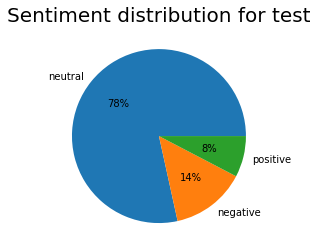

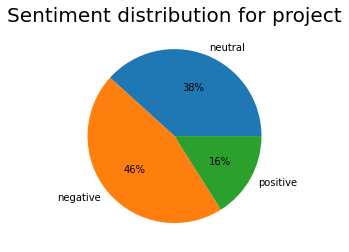

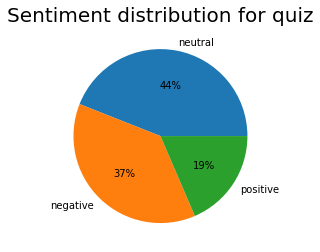

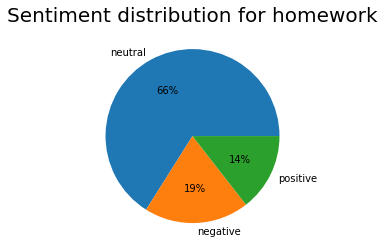

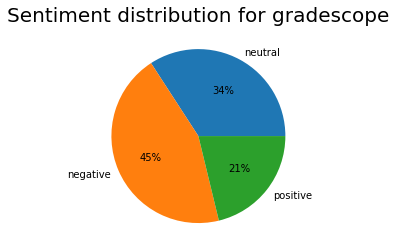

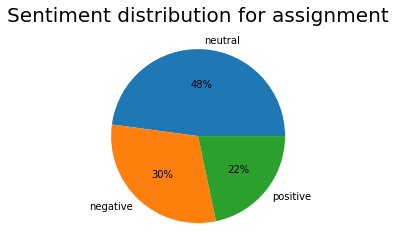

In [ ]:
labels = ['neutral', 'negative', 'positive']
colors = sns.color_palette("tab10")[0:len(labels)]
for i in range(len(aspects)):
  plt.title(label = "Sentiment distribution for " + aspects[i], fontsize = 20, loc ="center")
  plt.pie(pretrained_dict[aspects[i]], labels = labels, colors = colors, autopct='%.0f%%')
  plt.show()

In [ ]:
print(pretrained_dict)

{'test': [1139, 202, 111], 'project': [556, 663, 233], 'quiz': [639, 544, 269], 'homework': [959, 283, 210], 'gradescope': [496, 648, 308], 'assignment': [695, 442, 315]}


In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame.from_dict(pretrained_dict, orient = 'index')
df.to_csv('/content/drive/MyDrive/ABSA_output.csv')

In [ ]:
print(df)

               0    1    2
test        1139  202  111
project      556  663  233
quiz         639  544  269
homework     959  283  210
gradescope   496  648  308
assignment   695  442  315


In [ ]:
df_score = pd.DataFrame.from_dict(scores_, orient = 'columns')
df_score.to_csv('/content/drive/MyDrive/ABSA_output_w_score.csv')

In [ ]:
print(df_score)

                       test                project                   quiz  \
0      [0.979, 0.01, 0.011]  [0.819, 0.058, 0.123]  [0.793, 0.034, 0.173]   
1      [0.979, 0.01, 0.011]  [0.819, 0.058, 0.123]  [0.793, 0.034, 0.173]   
2      [0.979, 0.01, 0.011]  [0.819, 0.058, 0.123]  [0.793, 0.034, 0.173]   
3     [0.778, 0.155, 0.067]  [0.323, 0.645, 0.032]  [0.569, 0.406, 0.025]   
4     [0.924, 0.042, 0.033]  [0.541, 0.433, 0.026]  [0.653, 0.326, 0.021]   
...                     ...                    ...                    ...   
1447   [0.964, 0.016, 0.02]   [0.777, 0.19, 0.033]  [0.818, 0.172, 0.011]   
1448  [0.355, 0.552, 0.092]  [0.086, 0.862, 0.052]  [0.154, 0.788, 0.058]   
1449  [0.898, 0.094, 0.008]  [0.576, 0.401, 0.024]  [0.806, 0.167, 0.027]   
1450  [0.877, 0.065, 0.058]   [0.37, 0.384, 0.246]  [0.376, 0.151, 0.473]   
1451   [0.046, 0.02, 0.933]  [0.001, 0.001, 0.998]  [0.001, 0.003, 0.996]   

                   homework             gradescope             assignment  